In [ ]:
# =============================================================================
# Personal Loan Acceptance Prediction
# Dataset: Bank Marketing Dataset (UCI Machine Learning Repository) 
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, RocCurveDisplay
)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DATASET_PATH = "bank-full.csv"   
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
PALETTE       = "Set2"

plt.rcParams.update({
    "figure.dpi":     120,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "font.family":    "DejaVu Sans",
})



In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATASET_PATH, sep=";")
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [4]:

print(f"\n[INFO] Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n── Column names ────────────────────────────────────────────")
print(df.columns.tolist())


[INFO] Dataset loaded: 45,211 rows × 17 columns

── Column names ────────────────────────────────────────────
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [5]:
print("\n── Data types & non-null counts ─────────────────────────────")
print(df.info())


── Data types & non-null counts ─────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. DATA UNDERSTANDING & BASIC STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Descriptive statistics (numeric) ─────────────────────────")
print(df.describe())

print("\n── Missing values ───────────────────────────────────────────")
print(df.isnull().sum())

print("\n── Target class distribution ────────────────────────────────")
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")


── Descriptive statistics (numeric) ─────────────────────────
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  


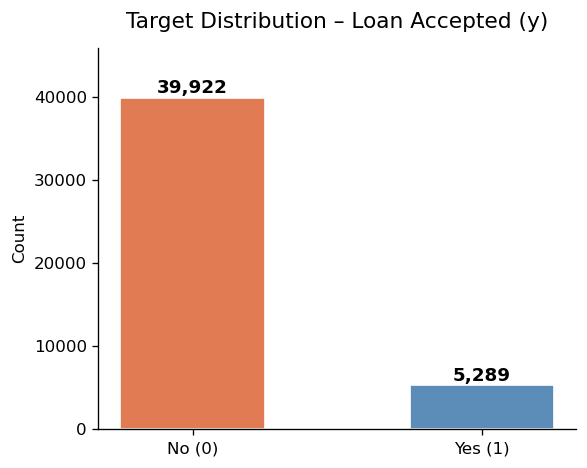

[PLOT] Target distribution saved.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────────────────────────────────────

# ── 5.1  Target distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["y"].value_counts()
bars = ax.bar(
    ["No (0)", "Yes (1)"], counts.values,
    color=["#E07B54", "#5B8DB8"], edgecolor="white", width=0.5
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Target Distribution – Loan Accepted (y)", fontsize=13, pad=12)
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("eda_target_distribution.png")
plt.show()
print("[PLOT] Target distribution saved.")

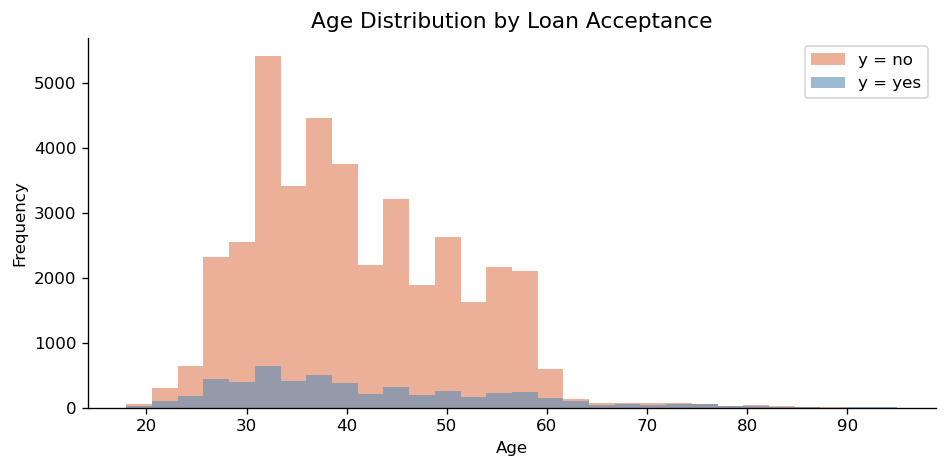

[PLOT] Age distribution saved.


In [8]:
# ── 5.2  Age distribution by outcome ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for label, colour in [("no", "#E07B54"), ("yes", "#5B8DB8")]:
    df[df["y"] == label]["age"].plot.hist(
        bins=30, alpha=0.6, color=colour, label=f"y = {label}", ax=ax)
ax.set_title("Age Distribution by Loan Acceptance", fontsize=13)
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("eda_age_distribution.png")
plt.show()
print("[PLOT] Age distribution saved.")

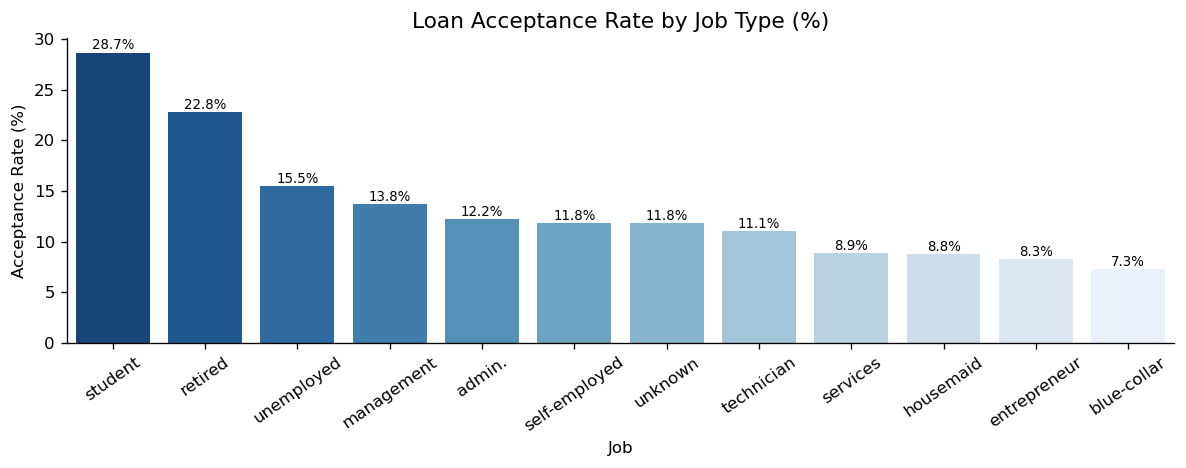

[PLOT] Job acceptance rate saved.


In [9]:
# ── 5.3  Job type vs acceptance rate ────────────────────────────────────────
job_accept = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
    .reset_index()
)
job_accept.columns = ["job", "acceptance_rate"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=job_accept, x="job", y="acceptance_rate",
            palette="Blues_r", ax=ax)
ax.set_title("Loan Acceptance Rate by Job Type (%)", fontsize=13)
ax.set_xlabel("Job")
ax.set_ylabel("Acceptance Rate (%)")
ax.tick_params(axis="x", rotation=35)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("eda_job_acceptance.png")
plt.show()
print("[PLOT] Job acceptance rate saved.")

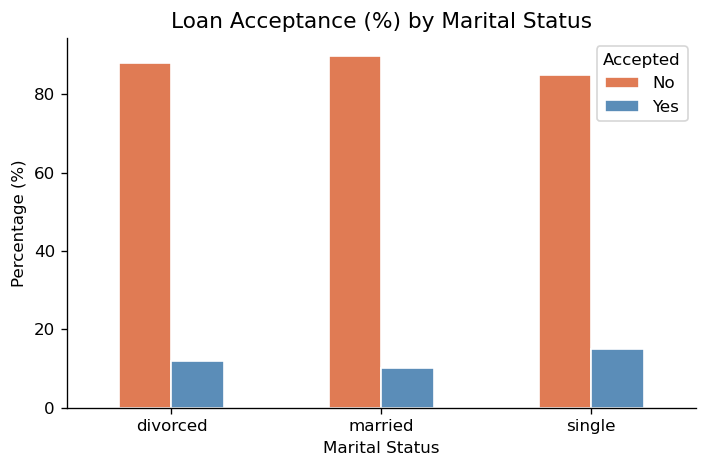

[PLOT] Marital acceptance saved.


In [10]:
# ── 5.4  Marital status vs acceptance ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
marital_ct = pd.crosstab(df["marital"], df["y"], normalize="index") * 100
marital_ct.plot(kind="bar", ax=ax, color=["#E07B54", "#5B8DB8"],
                edgecolor="white", width=0.5)
ax.set_title("Loan Acceptance (%) by Marital Status", fontsize=13)
ax.set_xlabel("Marital Status")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Accepted", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig("eda_marital_acceptance.png")
plt.show()
print("[PLOT] Marital acceptance saved.")

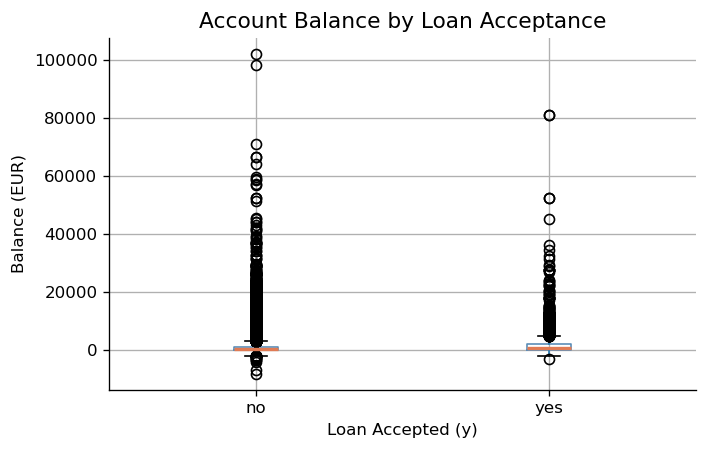

[PLOT] Balance boxplot saved.


In [11]:
# ── 5.5  Balance box-plot by outcome ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="balance", by="y", ax=ax,
           boxprops=dict(color="#5B8DB8"),
           medianprops=dict(color="#E07B54", linewidth=2))
ax.set_title("Account Balance by Loan Acceptance", fontsize=13)
ax.set_xlabel("Loan Accepted (y)")
ax.set_ylabel("Balance (EUR)")
plt.suptitle("")          # remove default pandas title
plt.tight_layout()
plt.savefig("eda_balance_boxplot.png")
plt.show()
print("[PLOT] Balance boxplot saved.")

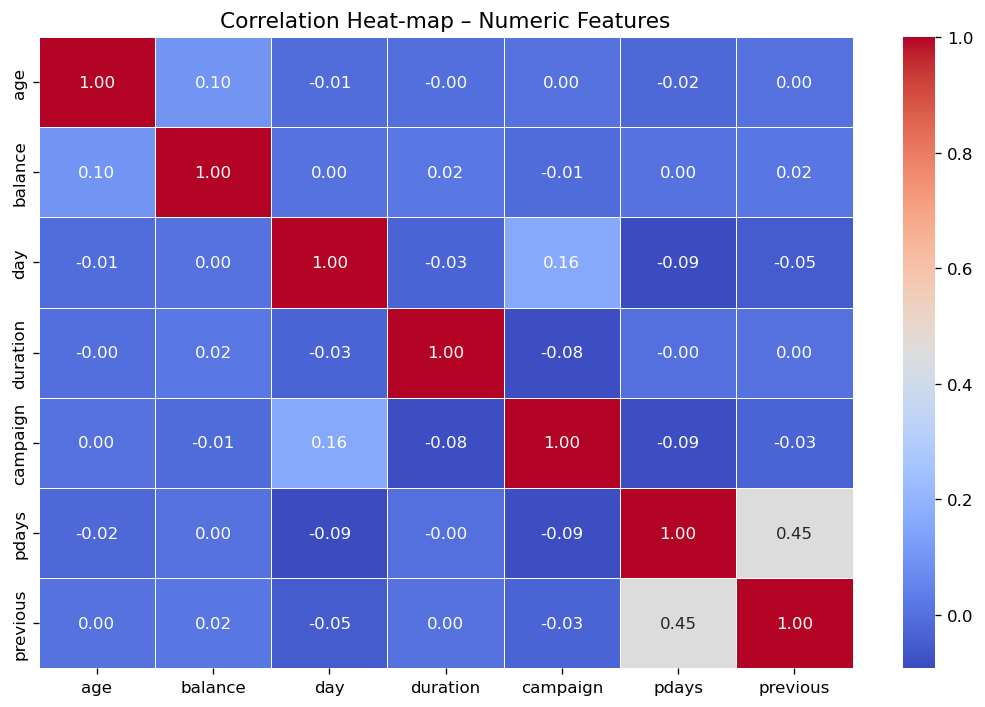

[PLOT] Correlation heatmap saved.


In [12]:
# ── 5.6  Correlation heat-map (numeric features) ────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    df[num_cols].corr(), annot=True, fmt=".2f",
    cmap="coolwarm", linewidths=0.5, ax=ax
)
ax.set_title("Correlation Heat-map – Numeric Features", fontsize=13)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png")
plt.show()
print("[PLOT] Correlation heatmap saved.")

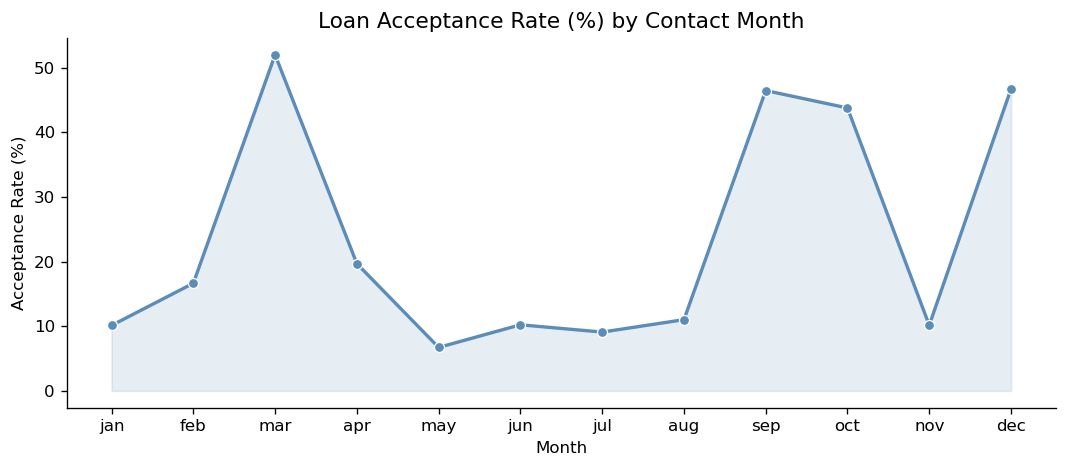

[PLOT] Monthly acceptance rate saved.


In [13]:
# ── 5.7  Contact month distribution ─────────────────────────────────────────
month_order = ["jan","feb","mar","apr","may","jun",
               "jul","aug","sep","oct","nov","dec"]
month_rate = (
    df.groupby("month")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reindex(month_order)
    .reset_index()
)
month_rate.columns = ["month", "acceptance_rate"]

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=month_rate, x="month", y="acceptance_rate",
             marker="o", color="#5B8DB8", linewidth=2, ax=ax)
ax.fill_between(month_rate["month"], month_rate["acceptance_rate"],
                alpha=0.15, color="#5B8DB8")
ax.set_title("Loan Acceptance Rate (%) by Contact Month", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Acceptance Rate (%)")
plt.tight_layout()
plt.savefig("eda_monthly_acceptance.png")
plt.show()
print("[PLOT] Monthly acceptance rate saved.")

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. DATA PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Preprocessing ────────────────────────────────────────────")

df_model = df.copy()

# Encode binary/ordinal columns with LabelEncoder
label_cols = ["default", "housing", "loan", "y"]
le = LabelEncoder()
for col in label_cols:
    df_model[col] = le.fit_transform(df_model[col])

# One-Hot Encode nominal categorical columns
nominal_cols = ["job", "marital", "education", "contact", "month", "poutcome"]
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

print(f"[INFO] Shape after encoding: {df_model.shape}")


── Preprocessing ────────────────────────────────────────────
[INFO] Shape after encoding: (45211, 43)


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. FEATURE / TARGET SPLIT  +  TRAIN-TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────
X = df_model.drop("y", axis=1)
y = df_model["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"[INFO] Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Feature scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

[INFO] Train: 36,168 | Test: 9,043


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. MODEL TRAINING
# ─────────────────────────────────────────────────────────────────────────────

# ── 8.1  Logistic Regression ─────────────────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000, solver="lbfgs", class_weight="balanced",
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_sc, y_train)

# ── 8.2  Decision Tree ───────────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=30,
    class_weight="balanced", random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'



───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
  Accuracy  : 0.8460 (84.60%)
  ROC-AUC   : 0.9079

  Classification Report:
                  precision    recall  f1-score   support

Not Accepted (0)       0.97      0.85      0.91      7985
    Accepted (1)       0.42      0.81      0.55      1058

        accuracy                           0.85      9043
       macro avg       0.70      0.83      0.73      9043
    weighted avg       0.91      0.85      0.87      9043

  5-Fold CV Accuracy : 0.8457 ± 0.0048


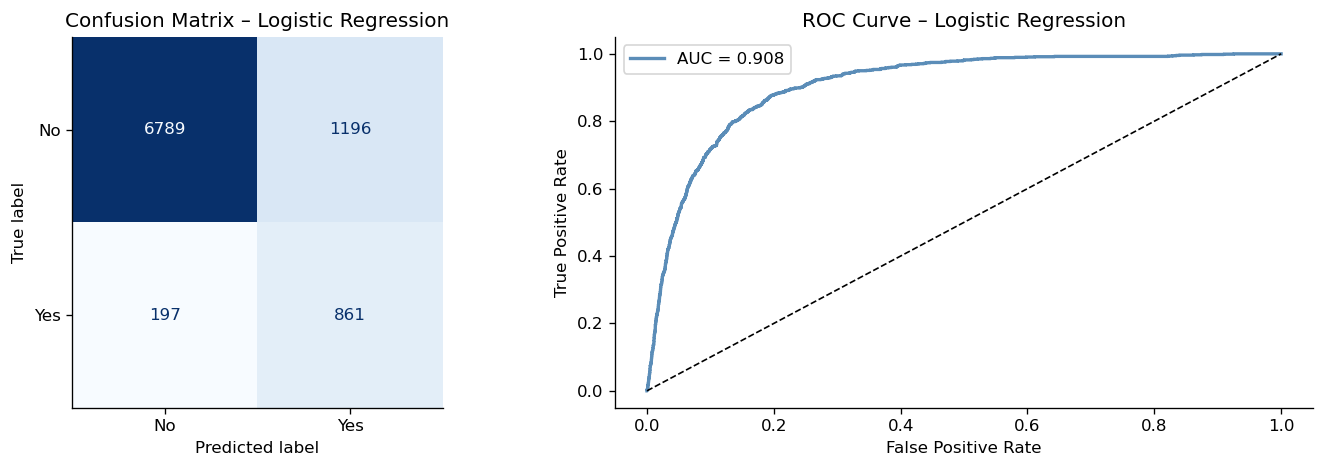

[PLOT] Evaluation plot saved for Logistic Regression.

───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
  Accuracy  : 0.7956 (79.56%)
  ROC-AUC   : 0.8903

  Classification Report:
                  precision    recall  f1-score   support

Not Accepted (0)       0.98      0.79      0.87      7985
    Accepted (1)       0.35      0.85      0.49      1058

        accuracy                           0.80      9043
       macro avg       0.66      0.82      0.68      9043
    weighted avg       0.90      0.80      0.83      9043

  5-Fold CV Accuracy : 0.7792 ± 0.0290


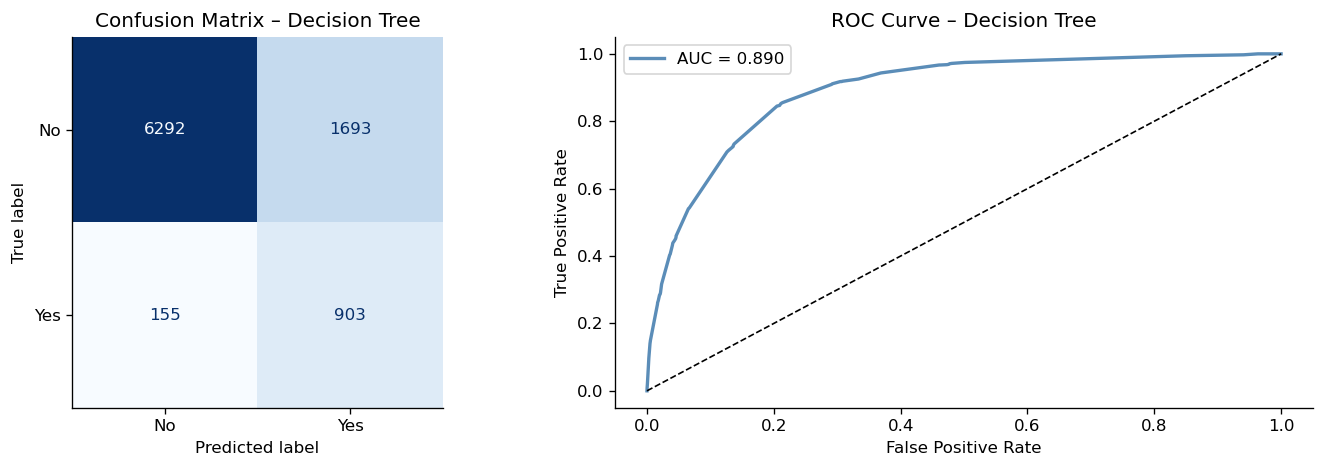

[PLOT] Evaluation plot saved for Decision Tree.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. MODEL EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(name, model, X_test_data, y_test_data,
                   y_prob=None, use_scaled=False):
    """Print full evaluation report and plot confusion matrix + ROC."""
    y_pred = model.predict(X_test_data)
    acc    = accuracy_score(y_test_data, y_pred)
    auc    = roc_auc_score(y_test_data, y_prob) if y_prob is not None else "N/A"

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    if y_prob is not None:
        print(f"  ROC-AUC   : {auc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test_data, y_pred,
                                target_names=["Not Accepted (0)", "Accepted (1)"]))

    # Cross-validation (5-fold stratified)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_test_data, y_test_data,
                                cv=cv, scoring="accuracy")
    print(f"  5-Fold CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_test_data, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"])
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"Confusion Matrix – {name}", fontsize=12)

    # ROC curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test_data, y_prob)
        axes[1].plot(fpr, tpr, color="#5B8DB8", lw=2,
                     label=f"AUC = {auc:.3f}")
        axes[1].plot([0, 1], [0, 1], "k--", lw=1)
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].set_title(f"ROC Curve – {name}", fontsize=12)
        axes[1].legend()
    else:
        axes[1].axis("off")

    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_")
    plt.savefig(f"eval_{safe_name}.png")
    plt.show()
    print(f"[PLOT] Evaluation plot saved for {name}.")
    return acc, auc


# Evaluate Logistic Regression
lr_prob = lr_model.predict_proba(X_test_sc)[:, 1]
lr_acc, lr_auc = evaluate_model(
    "Logistic Regression", lr_model, X_test_sc, y_test, y_prob=lr_prob
)

# Evaluate Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:, 1]
dt_acc, dt_auc = evaluate_model(
    "Decision Tree", dt_model, X_test, y_test, y_prob=dt_prob
)


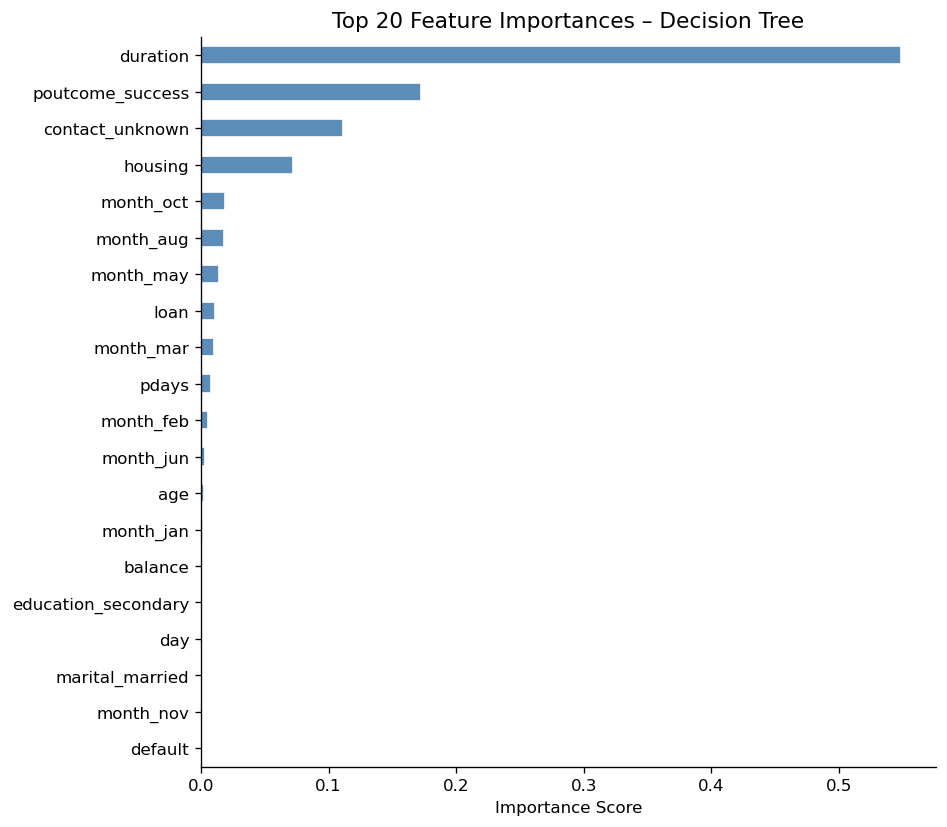

[PLOT] Feature importance saved.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. FEATURE IMPORTANCE (Decision Tree)
# ─────────────────────────────────────────────────────────────────────────────
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
top20.plot.barh(ax=ax, color="#5B8DB8", edgecolor="white")
ax.set_title("Top 20 Feature Importances – Decision Tree", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_decision_tree.png")
plt.show()
print("[PLOT] Feature importance saved.")

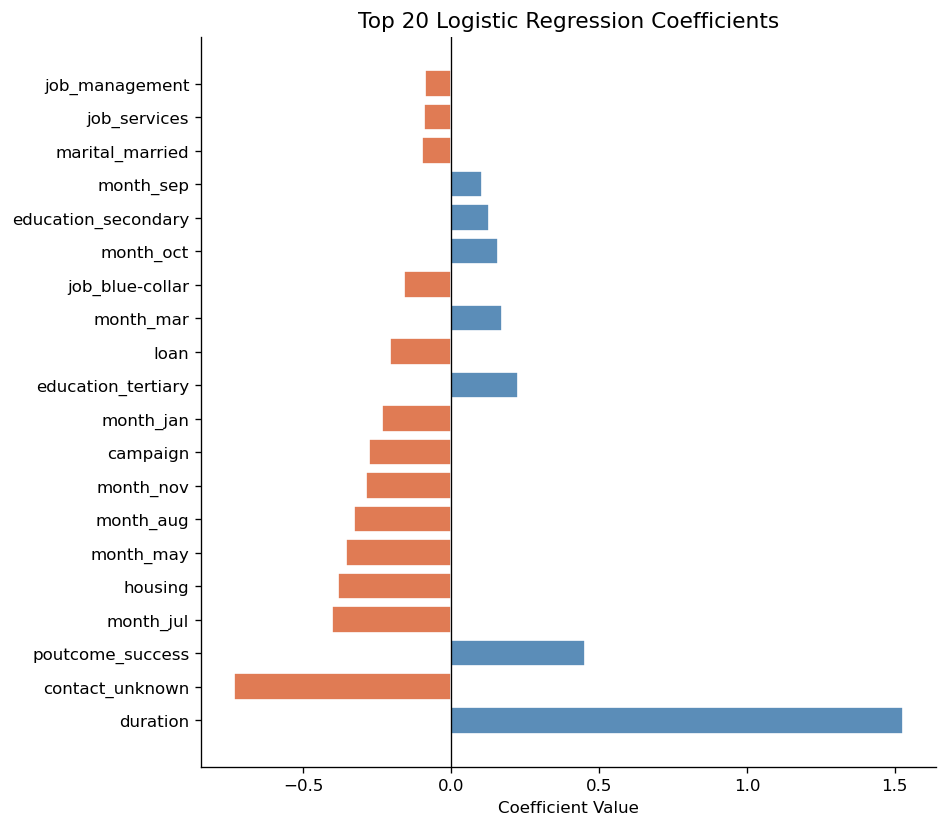

[PLOT] LR coefficients saved.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. LOGISTIC REGRESSION COEFFICIENTS (Top influencers)
# ─────────────────────────────────────────────────────────────────────────────
coeff_df = pd.DataFrame({
    "feature":     X.columns,
    "coefficient": lr_model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#5B8DB8" if c > 0 else "#E07B54" for c in coeff_df["coefficient"]]
ax.barh(coeff_df["feature"], coeff_df["coefficient"],
        color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Logistic Regression Coefficients", fontsize=13)
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("logistic_regression_coefficients.png")
plt.show()
print("[PLOT] LR coefficients saved.")

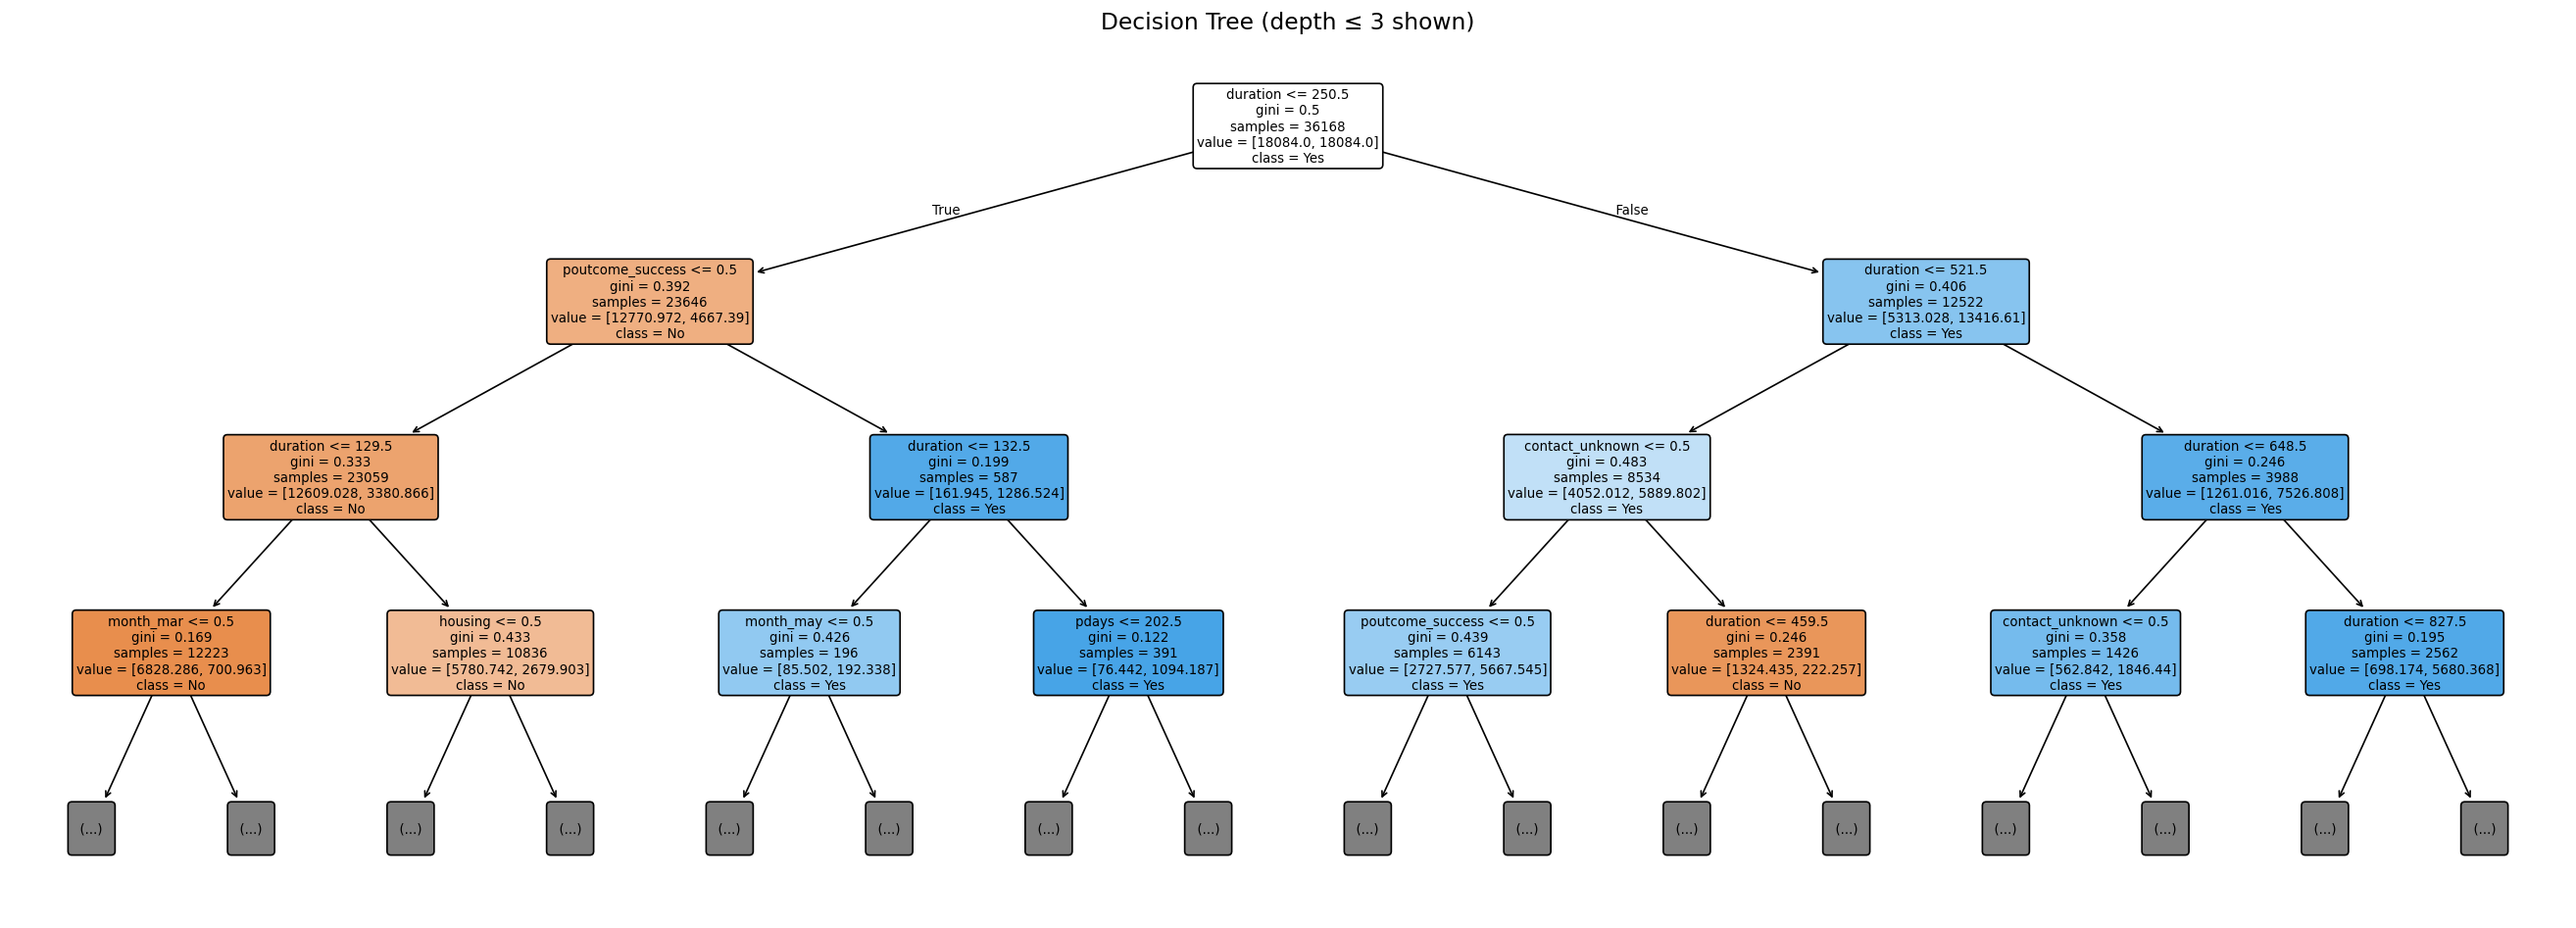

[PLOT] Decision tree visualization saved.


In [20]:

# ─────────────────────────────────────────────────────────────────────────────
# 12. DECISION TREE VISUALIZATION (shallow view)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_model, max_depth=3, feature_names=X.columns,
    class_names=["No", "Yes"], filled=True,
    rounded=True, fontsize=8, ax=ax
)
ax.set_title("Decision Tree (depth ≤ 3 shown)", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree_visualization.png")
plt.show()
print("[PLOT] Decision tree visualization saved.")

In [21]:

# ─────────────────────────────────────────────────────────────────────────────
# 13. BUSINESS INSIGHTS – CUSTOMER GROUP ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  BUSINESS INSIGHTS – Which customer groups accept the loan?")
print("=" * 65)

# Education
edu_rate = (
    df.groupby("education")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)
print("\nAcceptance rate by Education:")
print(edu_rate.round(2))

# Previous outcome
prev_rate = (
    df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)
print("\nAcceptance rate by Previous Campaign Outcome:")
print(prev_rate.round(2))

# Age bins
df["age_group"] = pd.cut(df["age"],
                          bins=[17, 25, 35, 45, 55, 65, 100],
                          labels=["18-25","26-35","36-45","46-55","56-65","65+"])
age_rate = (
    df.groupby("age_group", observed=True)["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)
print("\nAcceptance rate by Age Group:")
print(age_rate.round(2))

# Duration insight
dur_no  = df[df["y"] == "no"]["duration"].mean()
dur_yes = df[df["y"] == "yes"]["duration"].mean()
print(f"\nAvg call duration – Accepted: {dur_yes:.0f}s | Not accepted: {dur_no:.0f}s")


  BUSINESS INSIGHTS – Which customer groups accept the loan?

Acceptance rate by Education:
education
tertiary     15.01
unknown      13.57
secondary    10.56
primary       8.63
Name: y, dtype: float64

Acceptance rate by Previous Campaign Outcome:
poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: y, dtype: float64

Acceptance rate by Age Group:
age_group
65+      42.61
18-25    23.95
56-65    14.12
26-35    12.00
36-45     9.39
46-55     9.35
Name: y, dtype: float64

Avg call duration – Accepted: 537s | Not accepted: 221s


In [22]:

# ─────────────────────────────────────────────────────────────────────────────
# 14. MODEL COMPARISON SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
summary = pd.DataFrame({
    "Model":    ["Logistic Regression", "Decision Tree"],
    "Accuracy": [round(lr_acc, 4), round(dt_acc, 4)],
    "ROC-AUC":  [round(lr_auc, 4), round(dt_auc, 4)],
})
print(summary.to_string(index=False))


  MODEL COMPARISON SUMMARY
              Model  Accuracy  ROC-AUC
Logistic Regression    0.8460   0.9079
      Decision Tree    0.7956   0.8903


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# 15. CONCLUSION
# ─────────────────────────────────────────────────────────────────────────────
print("""

• The dataset is imbalanced (~88 % no, ~12 % yes); class   
  weighting was applied to both models.                     
• Duration of the last call is the strongest predictor  
  longer calls strongly correlate with acceptance.          
• Customers with a successful previous campaign outcome     
  (poutcome = success) have a much higher acceptance rate.  
• Students and retired customers show the highest           
  acceptance rates by job category.                         
• The age group 18-25 and 65+ show higher acceptance than 
  middle-aged groups.                                       
• Both models achieve solid AUC scores; choose Decision     
  Tree for interpretability, LR for stable probabilities.   

""")



• The dataset is imbalanced (~88 % no, ~12 % yes); class   
  weighting was applied to both models.                     
• Duration of the last call is the strongest predictor  
  longer calls strongly correlate with acceptance.          
• Customers with a successful previous campaign outcome     
  (poutcome = success) have a much higher acceptance rate.  
• Students and retired customers show the highest           
  acceptance rates by job category.                         
• The age group 18-25 and 65+ show higher acceptance than 
  middle-aged groups.                                       
• Both models achieve solid AUC scores; choose Decision     
  Tree for interpretability, LR for stable probabilities.   


